In [1]:
from lgdo import lh5
import os
import awkward as ak
import numpy as np
from matplotlib import pyplot as plt

In [2]:
pnum_cal = '00'; run_cal='037' # BEGe
pnum_phy_bg = '00'; run_phy  = '038' # IC
pnum_phy_signal = '05'; run_phy2  = '059' # IC
smoothing = ['01smooth', '03smooth', '20smooth']
dirname_cal={};dirname_phy_bg={};dirname_phy_signal={}
for i in range(len(smoothing)):
    dirname_cal[i] = "/mnt/atlas01/users/vogl/scarf/sp01/data/dsp_vary_current_shaping/"+smoothing[i]+"/cal/p" + pnum_cal + "/r" + run_cal
    dirname_phy_bg[i] = "/mnt/atlas01/users/vogl/scarf/sp01/data/dsp_vary_current_shaping/"+smoothing[i]+"/phy/p" + pnum_phy_bg + "/r" + run_phy
    dirname_phy_signal[i] = "/mnt/atlas01/users/vogl/scarf/sp01/data/dsp_vary_current_shaping/"+smoothing[i]+"/phy/p" + pnum_phy_signal + "/r" + run_phy2    
flist_cal={};flist_phy_bg={};flist_phy_signal={}
for i in range(len(smoothing)):
    flist_cal[i] = sorted(os.listdir(dirname_cal[i]))
    flist_phy_bg[i] = sorted(os.listdir(dirname_phy_bg[i]))
    flist_phy_signal[i] = sorted(os.listdir(dirname_phy_signal[i]))

In [3]:
pathlist_cal={};pathlist_phy_bg={};pathlist_phy_signal={}
for J in range(len(smoothing)):
    # print("cal:", len(flist_cal[i]), "phy_bg:", len(flist_phy_bg[i]), "phy_signal:", len(flist_phy_signal[i]))
    pathlist_phy_bg[J]= [os.path.join(dirname_phy_bg[i], f) for f in flist_phy_bg[i]]
    pathlist_cal[J] = [os.path.join(dirname_cal[i], f) for f in flist_cal[i]]
    pathlist_phy_signal[J] = [os.path.join(dirname_phy_signal[i], f) for f in flist_phy_signal[i]]

In [4]:
obj1_cal={};obj2_cal={};obj1_phy_bg={};obj2_phy_bg={};obj1_phy_signal={};obj2_phy_signal={}
for i in range(len(smoothing)):
    obj1_cal[i] = lh5.read("ch001/dsp", pathlist_cal[i])
    obj2_cal[i] = lh5.read("ch002/dsp", pathlist_cal[i])
    obj1_phy_bg[i] = lh5.read("ch001/dsp", pathlist_phy_bg[i])
    obj2_phy_bg[i] = lh5.read("ch002/dsp", pathlist_phy_bg[i])
    obj1_phy_signal[i] = lh5.read("ch001/dsp", pathlist_phy_signal[i])
    obj2_phy_signal[i] = lh5.read("ch002/dsp", pathlist_phy_signal[i])

In [9]:
ak_cal1 = {i: obj1_cal[i].view_as("ak") for i in range(len(smoothing))}
ak_phy_bg1 = {i: obj1_phy_bg[i].view_as("ak") for i in range(len(smoothing))}
ak_phy_signal1 = {i: obj1_phy_signal[i].view_as("ak") for i in range(len(smoothing))}
ak_cal2 = {i: obj2_cal[i].view_as("ak") for i in range(len(smoothing))}
ak_phy_bg2 = {i: obj2_phy_bg[i].view_as("ak") for i in range(len(smoothing))}
ak_phy_signal2 = {i: obj2_phy_signal[i].view_as("ak") for i in range(len(smoothing))}

In [10]:
def compare_field(ak_dict, field_name, smootha, smoothb):

    a = ak_dict[smootha][field_name]
    b = ak_dict[smoothb][field_name]
    percentage = len(np.where(a != b)[0])/len(a)
    return np.all(a == b),percentage

def compare_all_fields(ak_dict, smootha, smoothb):
    print(f"for p05r059 between smooth {1} and {20}")
    for field in ak_dict[smootha].fields:
        is_same, percentage = compare_field(ak_dict, field, smootha, smoothb)
        if not is_same:
            print(f"{field} is different (percentage of differences: {percentage*100:1.1f}%)")
        else:
            print(f"{field} is the same ")
            
compare_all_fields(ak_phy_signal2, 0, 1)

for p05r059 between smooth 1 and 20
A_max is the same 
A_max_mw is the same 
A_max_tri is the same 
A_min is the same 
A_min_mw is the same 
A_min_tri is the same 
Iasy is different (percentage of differences: 0.3%)
Iasy_left_area is different (percentage of differences: 0.0%)
Iasy_right_area is different (percentage of differences: 0.3%)
QDrift is different (percentage of differences: 6.3%)
bl_intercept is the same 
bl_intercept_win is the same 
bl_mean is the same 
bl_mean_win is the same 
bl_slope is the same 
bl_slope_diff is the same 
bl_slope_rms is the same 
bl_slope_win is the same 
bl_std is the same 
bl_std_win is the same 
chirp2sigma is different (percentage of differences: 0.0%)
chirp32 is the same 
dt_eff is different (percentage of differences: 6.3%)
lq50 is different (percentage of differences: 5.2%)
lq70 is different (percentage of differences: 5.1%)
lq75 is different (percentage of differences: 5.2%)
lq80 is different (percentage of differences: 5.2%)
lq85 is differen

In [16]:
ak_phy_signal1

{0: <Array [{A_max: 39.7, A_max_mw: ..., ...}, ...] type='12286495 * {A_max: fl...'>,
 1: <Array [{A_max: 39.7, A_max_mw: ..., ...}, ...] type='12286495 * {A_max: fl...'>,
 2: <Array [{A_max: 39.7, A_max_mw: ..., ...}, ...] type='12286495 * {A_max: fl...'>}

NameError: name 'cc' is not defined

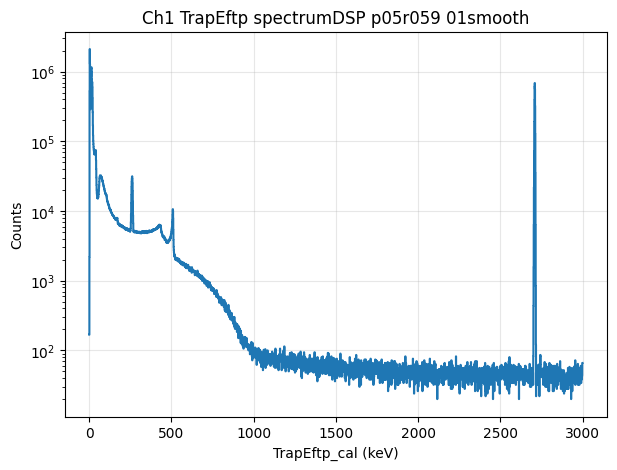

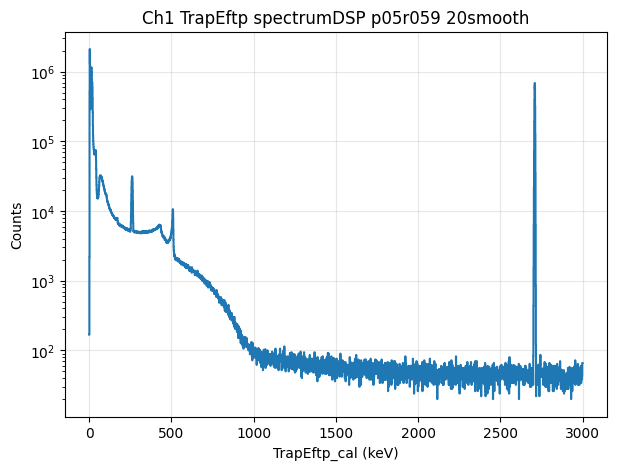

In [30]:

hist = {};edges = {};centers = {}
hist = {}
edges = {}
centers = {}
a = ak_phy_signal1[0]['A_max_mw']
b = ak_phy_signal1[2]["A_max_mw"]

for i,j in zip(range(2),['01smooth','20smooth']):

    hist[i], edges[i] = np.histogram([a,b], bins=3000, range=(0,3000))
    centers[i] = 0.5 * (edges[i][:-1] + edges[i][1:])
    plt.figure(figsize=(7,5))
    plt.step(centers[i], hist[i], where="mid")
    plt.yscale("log")

    plt.xlabel("TrapEftp_cal (keV)")
    plt.ylabel("Counts")

#     if i < 2:
#         label = "cal "+smoothing+" p" + pnum_cal + "r" + run_cal
#         ch = i + 1
#     elif i < 4:
#         label = "bg "+smoothing+" p" + pnum_phy_bg + "r" + run_phy_bg
#         ch = i - 1
#     else:
#         label = "signal "+smoothing+" p" + pnum_phy_signal + "r" + run_phy_signal
#         ch = i - 3

    plt.title(f"Ch1 TrapEftp spectrum"+'DSP p05r059 '+j)
    plt.grid(alpha=0.3)


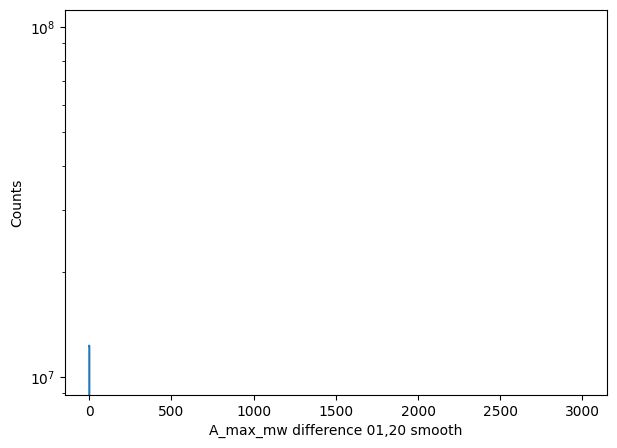

In [31]:
c = a - b

hist, edges = np.histogram(c, bins=3000, range=(0,3000))

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(7,5))
plt.step(centers, hist, where="mid")

plt.yscale("log")
plt.xlabel("A_max_mw difference 01,20 smooth")
plt.ylabel("Counts")
plt.show()